In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Algerian_forest_fires_cleaned_dataset.csv")

In [5]:
df.head(5)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [9]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [13]:
df.drop(['day','month','year'], axis = 1, inplace = True)

In [15]:
df.head(5)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [17]:
df.isnull().sum()

Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [21]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [23]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0,1)

In [25]:
df.head(10)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0
5,31,67,14,0.0,82.6,5.8,22.2,3.1,7.0,2.5,1,0
6,33,54,13,0.0,88.2,9.9,30.5,6.4,10.9,7.2,1,0
7,30,73,15,0.0,86.6,12.1,38.3,5.6,13.5,7.1,1,0
8,25,88,13,0.2,52.9,7.9,38.8,0.4,10.5,0.3,0,0
9,28,79,12,0.0,73.2,9.5,46.3,1.3,12.6,0.9,0,0


In [27]:
X = df.drop('FWI', axis = 1)
y = df['FWI']

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [31]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [35]:
feat = correlation(X_train, 0.90)

In [37]:
X_train.drop(feat, axis = 1, inplace = True)
X_test.drop(feat, axis = 1, inplace = True)

In [39]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Mean absolute error 0.48650652708864783
R2 Score 0.9766609638944738


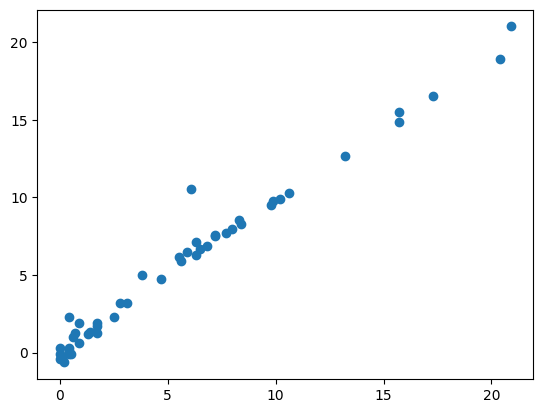

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

In [43]:
print("Hello")

Hello


Mean absolute error 0.46854974861741994
R2 Score 0.9770043277170577


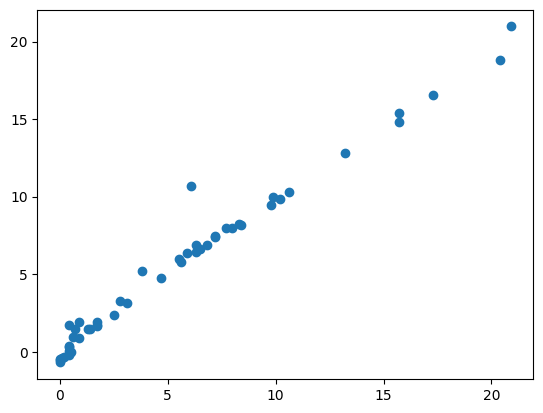

In [45]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)
lassocv.alpha_
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)


In [47]:
import pandas as pd

# ১. ফিচারগুলোর নাম এবং তাদের কো-efficient নিয়ে একটি ডেটাফ্রেম তৈরি করা
feature_importance = pd.DataFrame({
    'Feature_Name': X_train.columns,              # আপনার আসল ডাটাসেটের কলামগুলোর নাম
    'Coefficient_Value': lassocv.coef_            # ল্যাসো মডেলের দেওয়া ওজন বা সহগ
})

# ২. বোঝার সুবিধার্থে কো-efficient এর মান বড় থেকে ছোট আকারে সাজানো
feature_importance = feature_importance.sort_values(by='Coefficient_Value', ascending=False)

# ৩. পুরো তালিকাটি প্রিন্ট করা
print("--- সব ফিচারের কো-efficient তালিকা ---")
print(feature_importance)

--- সব ফিচারের কো-efficient তালিকা ---
  Feature_Name  Coefficient_Value
7          ISI           5.014737
5          DMC           2.957629
6           DC           0.835883
8      Classes           0.148104
3         Rain           0.012634
0  Temperature          -0.000000
2           Ws          -0.002502
1           RH          -0.055083
9       Region          -0.135215
4         FFMC          -0.580209


In [49]:
dropped_features = feature_importance[feature_importance['Coefficient_Value'] == 0]
print(f"ল্যাসো মডেল মোট {len(dropped_features)} টি ফিচার বাদ দিয়েছে।")
print(dropped_features['Feature_Name'])

ল্যাসো মডেল মোট 1 টি ফিচার বাদ দিয়েছে।
0    Temperature
Name: Feature_Name, dtype: object


Mean absolute error 1.6097309284290635
R2 Score 0.8724247300488145


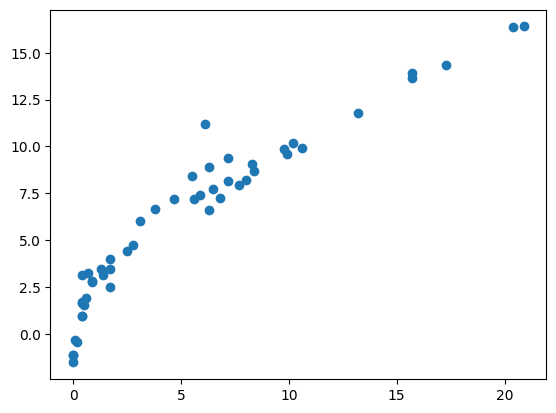

In [51]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)